# Pagerank - Sprawozdanie - Jakub Własiewicz

Niektóre funkcje są zdefiniowane na potrzebę podglądu, ale na wypadek są też zincludowane.

### Importy

In [1]:
include("src/pagerank.jl");
include("src/simplerank.jl");
include("src/plotting.jl")
using .simplerank
using .pagerank
using .plotting
using Karnak
using Arpack
using LinearAlgebra
using Graphs
using Plots
using Statistics
import Graphs: pagerank as pagerank_lib

## Zadanie 1 - Prosty ranking

Ranking wierzchołka $u$ definujemy w następujący sposób:

$$ r(u) = d \sum_{v \in B_u} \frac{r(v)}{N_v}$$

Gdzie $d \in (0,1]$ jest parametrem tłumienia, $B_u$ poprzednikiami $u$, $N_v$ stopniem wyjściowym $v$.
Równanie w postaci macierzowej sprowadza się do:

$$ \textbf{r} = d \textbf{Ar} $$
$$ A_{u,v} = \begin{cases}
            \frac{1}{N_v} & \text{jeśli $(v, u) \in E$,} \\
            0 & \text{w.p.p.}\\ \end{cases}

Możemy znaleźć rozwiązanie za pomocą metody potęgowej, otrzymując wektor własny macierzy $d\textbf{A}$ odpowiadający wartości własnej $\lambda = 1$

In [2]:
function graph_simplerank(graph, d=1.0, iters=100000, ϵ=10E-30)
    @assert 0.0 < d <= 1.0
    A = matrix_A(graph) # stworzenie macierzy A z grafu
    v = power_iteration(d * A, iters, ϵ)
    v[v.<ϵ] .= 0.0 # zastąpienie wartości < ϵ zerem
    return any(v .< 0) ? -v : v # jeśli wektor jest cały ujemny, zmień znak
end

graph_simplerank (generic function with 4 methods)

### Graf Erdős–Rényi

In [3]:
n = 15
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
while !all(outdegree(erdos) .> 0) # spójność
    erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
end
A = matrix_A(erdos)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych 

15-element Vector{Float64}:
  3.469446951953614e-17
 -4.163336342344337e-17
 -2.7755575615628914e-17
 -7.632783294297951e-17
  1.734723475976807e-18
 -4.163336342344337e-17
  8.326672684688674e-17
  7.632783294297951e-17
  9.71445146547012e-17
  3.469446951953614e-18
  2.7755575615628914e-17
 -6.938893903907228e-18
 -7.632783294297951e-17
 -3.469446951953614e-17
  0.0

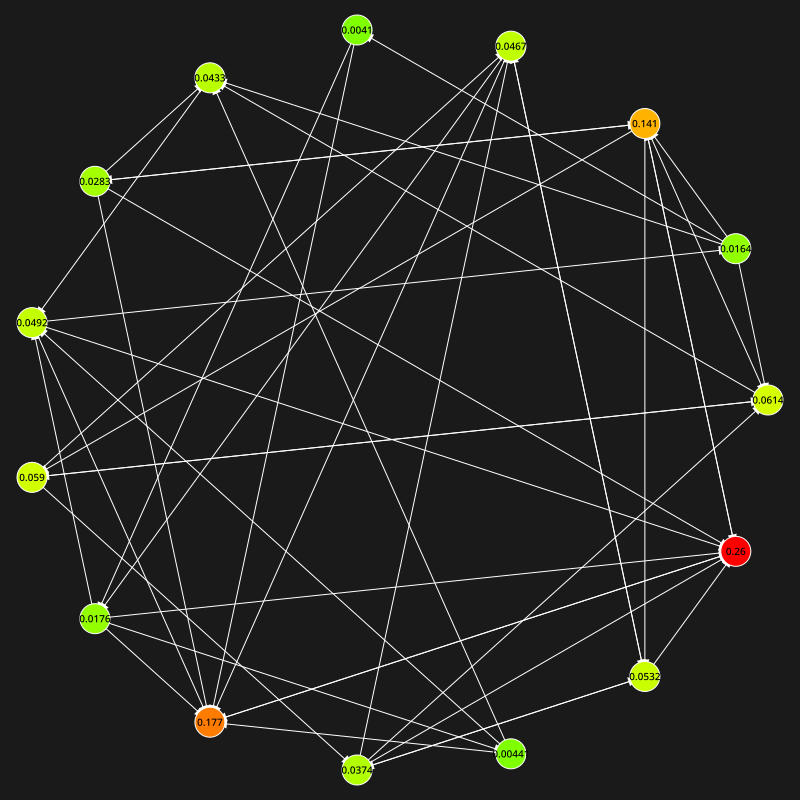

In [4]:
d = 0.85
plotting.plot_pagerank(erdos, d, simplerank.graph_simplerank, shell)

### Graf Scale-Free - Barabási–Albert Model

In [5]:
n = 15
bara = barabasi_albert(n,Int(round(n/3)), is_directed=true, complete=true)
A = matrix_A(bara)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych 

15-element Vector{Float64}:
 -1.6653345369377348e-16
  0.0
  1.1102230246251565e-16
  0.0
  8.326672684688674e-17
  8.427352498489094e-17
  1.91753059827062e-17
  1.2231920019116956e-18
  1.942281991757709e-17
  8.441440271250657e-18
  3.817275745754276e-17
  2.255068762823547e-17
  1.95300185781097e-17
  4.591514958290682e-18
  5.724255826626216e-18

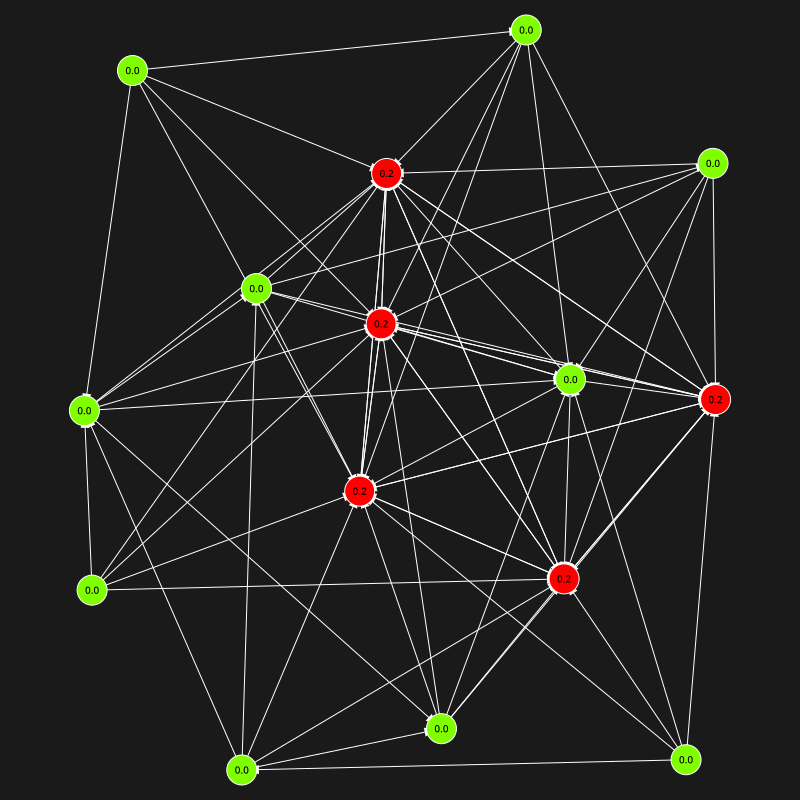

In [6]:
d = 0.85
plotting.plot_pagerank(bara, d, simplerank.graph_simplerank, stress)

### Graf Small World - Watts-Strogatz model

In [7]:
n = 15
watts_stro = watts_strogatz(n, n ÷ 2, 0.6, is_directed=true)
while !all(outdegree(watts_stro) .> 0) # spójność
    watts_stro = watts_strogatz(n, n ÷ 2, 0.6, is_directed=true)
end
A = matrix_A(watts_stro)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych

15-element Vector{Float64}:
 -2.0816681711721685e-17
  3.469446951953614e-17
 -6.938893903907228e-17
 -2.7755575615628914e-17
  6.938893903907228e-17
  1.8041124150158794e-16
 -4.163336342344337e-17
  1.3877787807814457e-17
  4.163336342344337e-17
  2.0816681711721685e-17
 -1.3877787807814457e-16
 -8.326672684688674e-17
  1.491862189340054e-16
 -8.326672684688674e-17
 -8.326672684688674e-17

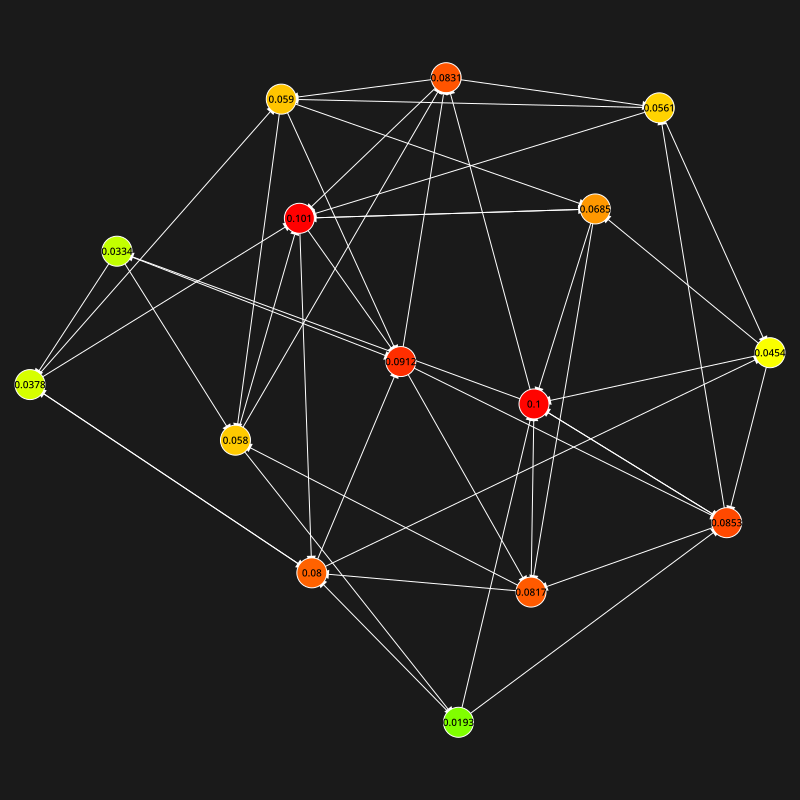

In [8]:
d = 0.85
plotting.plot_pagerank(watts_stro, d, simplerank.graph_simplerank, stress)

## Zadanie 2 - Pagerank

Tym razem mamy równanie:

$$ r(u) = d \sum_{v \in B_u} \frac{r(v)}{N_v} + (1-d)e(u)$$

Gdzie $\mathbf{e}$ jest wektorem preferencji teleportacji, oraz wprowadzimy $\hat{A}$ - macierz w których zerowe kolumny wiszących wierzchołków są zastąpione wektorem $\mathbf{e}$. $\mathbf{c}$ to wskaźnik wiszących.

$$ \hat{A} = A + \mathbf{e c}^T$$

In [9]:
function matrix_Â(graph, e)
    A = matrix_A(graph)
    n = nv(graph)
    c = zeros(n)
    c[outdegree(graph).==0] .= 1.0
    return A + e * c'
end

matrix_Â (generic function with 1 method)

Zastosujemy sprytną metodę potęgową, zamiast liczyć bezpośrednio dla macierzy $d \mathbf{A} + (1-d) \mathbf{ec}^T$ - pamięciowo $O(n^2)$

In [10]:
function pagerank_power_iter_with_mass_re(A, d, e, ϵ) #A - macierz, d - wsp. tlum. , e - wektor teleportacji
    rᵢ = e
    rᵢ₊₁ = rᵢ
    δ = Inf
    while ϵ < δ
        rᵢ = rᵢ₊₁
        rᵢ₊₁ = d * A * rᵢ
        ρ = norm(rᵢ, 1) - norm(rᵢ₊₁, 1)
        rᵢ₊₁ += ρ * e
        δ = norm(rᵢ₊₁ - rᵢ, 1)
    end
    return rᵢ
end

pagerank_power_iter_with_mass_re (generic function with 1 method)

Wykorzystamy znowu graf Erdős–Rényi

In [11]:
n = 25
d = 0.85
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
pg = pagerank.graph_pagerank(erdos, d) # sprytna metoda potegowa
pg_basic = pagerank.graph_pagerank_basic(erdos, d) # naiwna
pg_lib = pagerank_lib(erdos, d) # biblioteczna
display(pg - pg_basic)
display(pg - pg_lib)
display(pg_basic - pg_lib)

25-element Vector{Float64}:
  2.42861286636753e-17
 -9.71445146547012e-17
 -1.1102230246251565e-16
 -3.677613769070831e-16
 -8.847089727481716e-17
 -8.743006318923108e-16
  5.759281940243e-16
  1.942890293094024e-16
 -1.5265566588595902e-16
 -5.828670879282072e-16
  ⋮
 -1.942890293094024e-16
  3.677613769070831e-16
 -2.983724378680108e-16
  7.632783294297951e-17
 -1.1102230246251565e-16
 -2.0816681711721685e-16
 -1.3877787807814457e-17
  2.914335439641036e-16
 -2.7755575615628914e-17

25-element Vector{Float64}:
 -1.41139826326242e-7
  3.060089113354758e-8
 -2.46680688341383e-7
  5.003873516720714e-7
  1.5303611799848127e-7
  1.1229757071462565e-7
 -9.962237001864827e-7
 -3.323258720121236e-7
 -1.9727768033050985e-7
 -4.5416481750382154e-7
  ⋮
  8.161061289743698e-7
  1.5317240911749685e-7
  1.5110334362217204e-7
 -4.6742013641576374e-8
  2.735527329170151e-7
  2.52404268784312e-7
 -4.349948296220041e-7
  2.2818989173917226e-7
 -2.886187322956313e-7

25-element Vector{Float64}:
 -1.4113982635052813e-7
  3.0600891230692095e-8
 -2.466806882303607e-7
  5.003873520398328e-7
  1.5303611808695217e-7
  1.1229757158892628e-7
 -9.962237007624108e-7
 -3.3232587220641263e-7
 -1.9727768017785419e-7
 -4.5416481692095445e-7
  ⋮
  8.161061291686589e-7
  1.5317240874973548e-7
  1.5110334392054448e-7
 -4.674201371790421e-8
  2.735527330280374e-7
  2.524042689924788e-7
 -4.349948296081263e-7
  2.281898914477387e-7
 -2.886187322678757e-7

Różnice są nieznacze, rzędu $ \approx 10^{-7}$ (dla $n=25$), więc w tym przypadku można twierdzić o poprawności zaimplementowanej funkcji.
Możemy też sprawdzić średnie różnice pomiędzy implementacjami dla różnych $d$:

In [23]:
avgs = []
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
for d ∈ [0.5, 0.6, 0.75, 0.85, 0.9]
    pg = pagerank.graph_pagerank(erdos, d) # sprytna metoda potegowa
    pg_basic = pagerank.graph_pagerank_basic(erdos, d) # naiwna
    pg_lib = pagerank_lib(erdos, d) # biblioteczna
    push!(avgs, mean(mean.([pg - pg_basic, pg - pg_lib, pg_basic - pg_lib])))
end
display(avgs)

5-element Vector{Any}:
  3.256654205567125e-17
  3.3214172153369263e-17
  1.2397490441647583e-17
  4.39000687653864e-17
 -2.2482016248659418e-17

┌ Info: power iteration return because of norm < ϵ
└ @ Main.pagerank.simplerank /home/hyperbarq/Documents/pagerank/src/simplerank.jl:25


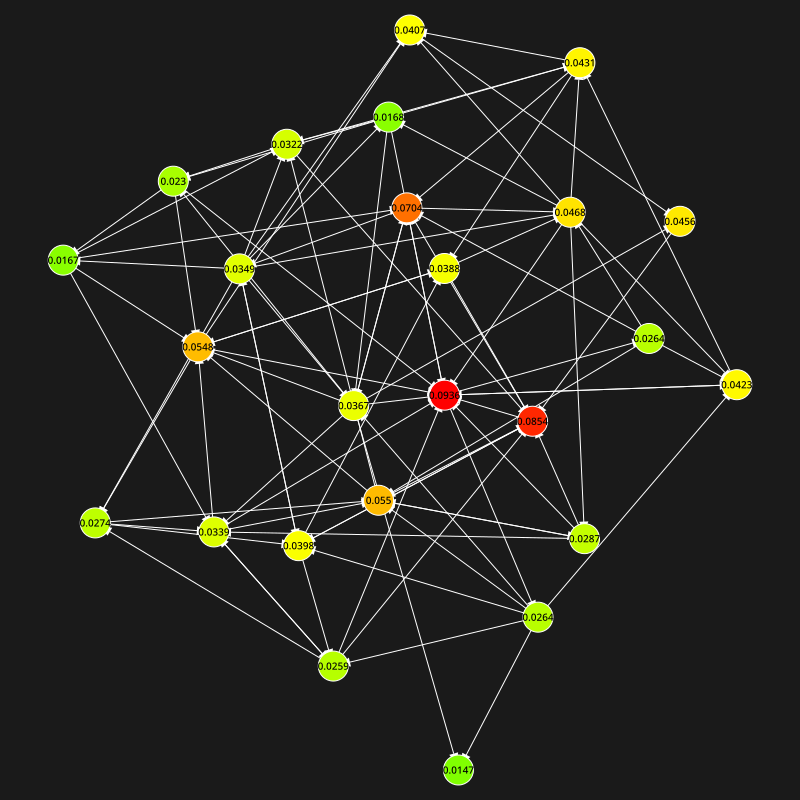

In [24]:
plotting.plot_pagerank(erdos, d, pagerank.graph_pagerank, stress)

Sprawdźmy wykres δᵢ = ||rᵢ₊₁ - rᵢ||₁ w półlogarytmicznej skali.

"Nachylenie: -0.6844731418951929 vs teoretyczne : -0.16251892949777494"

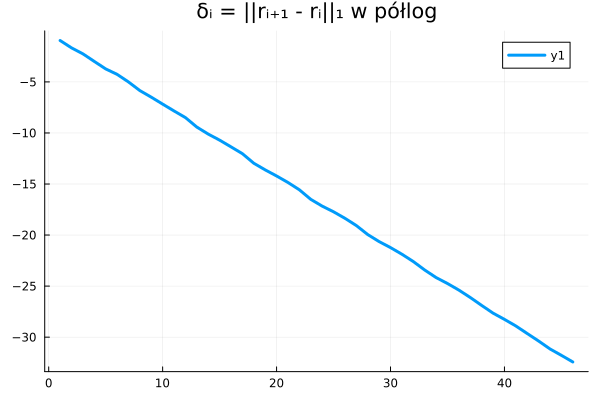

In [14]:
pg, delta_v = pagerank.graph_pagerank(erdos, d, Val(:delta_data))
log_delta_v = log.(delta_v)
display("Nachylenie: $((log_delta_v[end] - log_delta_v[1]) / length(delta_v)) vs teoretyczne : $(log(d))")
plot(1:length(delta_v), log_delta_v, title="δᵢ = ||rᵢ₊₁ - rᵢ||₁ w półlog", linewidth=3)

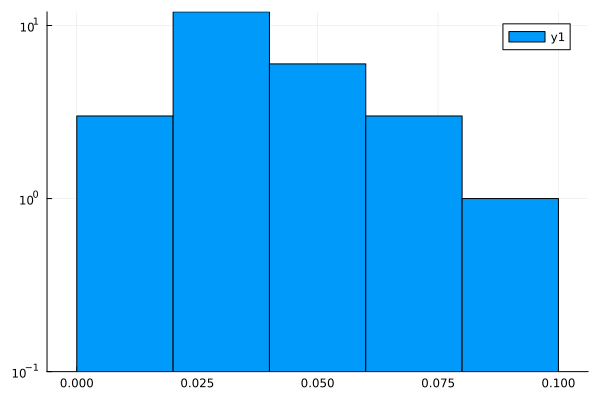

In [15]:
histogram(pg, yaxis=(:log10))